In [31]:

import zarr
from pathlib import Path

import geopandas as gpd
import pandas as pd

import json
from pathlib import Path

import geopandas as gpd

from fastfuels_sdk import (
    Domain,
    Grids,
    Inventories,
    TreeGridBuilder,
)

from shapely.geometry import box
import matplotlib.pyplot as plt
import zipfile


# Load Wade's Treelist

In [27]:
# Paths
DATA_DIR = Path("data")
INPUT_GPKG = DATA_DIR / "final_detected_tree_tops.gpkg"

# Load the GeoPackage
print(f"Loading {INPUT_GPKG}...")
trees = gpd.read_file(INPUT_GPKG)
print(f"Loaded {len(trees)} trees")

# Create a GeoDataFrame that is the extent (bounding box) of trees
minx, miny, maxx, maxy = trees.total_bounds
detected_treetops_extent = gpd.GeoDataFrame(
    {"name": ["trees_extent"]},
    geometry=[box(minx, miny, maxx, maxy)],
    crs=trees.crs,
)

Loading data/final_detected_tree_tops.gpkg...
Loaded 51242 trees


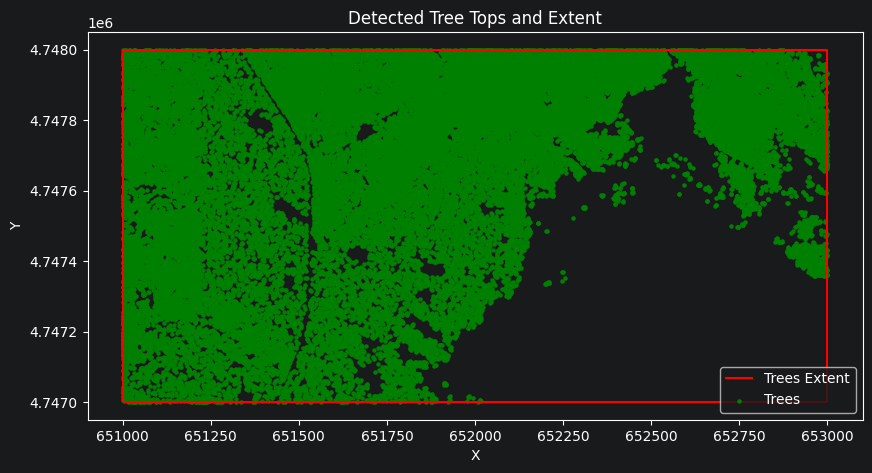

In [28]:
# Plot the trees and their extent
fig, ax = plt.subplots(figsize=(10, 10))
detected_treetops_extent.boundary.plot(ax=ax, color="red", label="Trees Extent")
trees.plot(ax=ax, color="green", markersize=5, label="Trees")
ax.set_title("Detected Tree Tops and Extent")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
plt.show()

# FastFuels

### Prep Wade's Treelist for FastFuels

In [9]:
output_file_name = DATA_DIR / "trees_for_fastfuels_upload.csv"
output = pd.DataFrame({
    "SPCD": 122,  # Ponderosa Pine for all trees
    "STATUSCD": 1,  # All live
    "DIA": trees["dbh_cm"].values,
    "HT": trees["tree_height_m"].values,
    "CR": (trees["crown_length_m"] / trees["tree_height_m"]).values,
    "X": trees.geometry.x.values,
    "Y": trees.geometry.y.values,
    "CROWN_FUEL_LOAD": trees["cruz_crown_biomass_kg"].values,
    "MAX_CROWN_RADIUS": (trees["crown_dia_m"] / 2).values,
})

# Clamp CR to [0, 1] range
output["CR"] = output["CR"].clip(0, 1)

# Drop rows with NaN in required columns
required = ["SPCD", "STATUSCD", "DIA", "HT", "CR", "X", "Y", "CROWN_FUEL_LOAD", "MAX_CROWN_RADIUS"]
before = len(output)
output = output.dropna(subset=required)
after = len(output)
if before != after:
    print(f"Dropped {before - after} rows with NaN values")

print(f"Output: {len(output)} trees")
print(f"Columns: {list(output.columns)}")
print(f"\nSample:\n{output.head()}")
print(f"\nSummary:\n{output.describe()}")

# Save to CSV
output.to_csv(output_file_name, index=False)
print(f"\nSaved to {output_file_name}")

Output: 51242 trees
Columns: ['SPCD', 'STATUSCD', 'DIA', 'HT', 'CR', 'X', 'Y', 'CROWN_FUEL_LOAD', 'MAX_CROWN_RADIUS']

Sample:
   SPCD  STATUSCD        DIA     HT        CR           X            Y  \
0   122         1  15.558223   9.35  0.625107  651000.125  4747999.875   
1   122         1  10.337119   6.55  0.515733  651018.625  4747999.875   
2   122         1  21.345815  12.07  0.875725  651034.625  4747999.875   
3   122         1  15.447166   9.32  0.643987  651035.875  4747999.875   
4   122         1  19.522790  11.32  0.694452  651072.625  4747999.875   

   CROWN_FUEL_LOAD  MAX_CROWN_RADIUS  
0        14.175397          1.074185  
1         3.338541          0.732904  
2         3.887113          0.661571  
3         0.902952          0.423142  
4         9.865383          1.007280  

Summary:
          SPCD  STATUSCD           DIA            HT            CR  \
count  51242.0   51242.0  51242.000000  51242.000000  51242.000000   
mean     122.0       1.0     20.869158     1

### Run FastFuels for Wade's Treelist

In [11]:
import os

os.environ["FASTFUELS_API_KEY"] = "test-api-key"

TREELIST_CSV = DATA_DIR / "trees_for_fastfuels_upload.csv"

# ── Domain ───────────────────────────────────────────────────────────────────
print("Creating domain...")
domain = Domain.from_geodataframe(
    geodataframe=detected_treetops_extent,
    name="sycan-fuels-initiative",
    description="Sycan fuels initiative site with custom crown fuel load and crown radius",
    horizontal_resolution=2.0,
    vertical_resolution=1.0,
)
domain_id = domain.id
print(f"Domain: {domain.name} ({domain_id})")

# ── Tree Inventory ───────────────────────────────────────────────────────────
print(f"\nUploading tree inventory from {TREELIST_CSV}...")
tree_inventory = Inventories.from_domain_id(domain_id).create_tree_inventory_from_file_upload(
    TREELIST_CSV
)
tree_inventory = tree_inventory.wait_until_completed(verbose=False)
print(f"Tree inventory status: {tree_inventory.status}")

# ── Tree Grid ────────────────────────────────────────────────────────────────
print("\nBuilding tree grid...")
tree_grid = (
    TreeGridBuilder(domain_id=domain_id)
    .with_bulk_density_from_tree_inventory()
    .with_spcd_from_tree_inventory()
    .build()
)
tree_grid = tree_grid.wait_until_completed(verbose=False, in_place=True)
print(f"Tree grid status: {tree_grid.status}")

# ── Grid Export ───────────────────────────────────────────────────────────────
print("\nExporting grids to zarr...")
grid_export = Grids.from_domain_id(domain_id).create_export("zarr")
grid_export = grid_export.wait_until_completed(verbose=False, in_place=True)

# Save the data
output_path = DATA_DIR / "canopy_fuel_grid.zip"
grid_export.to_file(str(output_path))
print(f"\nExported to {output_path}")


Creating domain...
Domain: sycan-fuels-initiative (bc934eeae8fb4e03a037316a89b03219)

Uploading tree inventory from data/trees_for_fastfuels_upload.csv...
Tree inventory has status `JobStatus.COMPLETED` (5.00s)
Tree inventory status: JobStatus.COMPLETED

Building tree grid...
Tree grid has status `JobStatus.PENDING` (5.00s)
Tree grid has status `JobStatus.PENDING` (10.00s)
Tree grid has status `JobStatus.PENDING` (15.00s)
Tree grid has status `JobStatus.PENDING` (20.00s)
Tree grid has status `JobStatus.RUNNING` (25.00s)
Tree grid has status `JobStatus.RUNNING` (30.00s)
Tree grid has status `JobStatus.RUNNING` (35.00s)
Tree grid has status `JobStatus.RUNNING` (40.00s)
Tree grid has status `JobStatus.RUNNING` (45.00s)
Tree grid has status `JobStatus.RUNNING` (50.00s)
Tree grid has status `JobStatus.COMPLETED` (55.00s)
Tree grid status: JobStatus.COMPLETED

Exporting grids to zarr...
Export has status `ExportStatus.PENDING` (5.00s)
Export has status `ExportStatus.PENDING` (10.00s)
Export 

### Look at the FastFuels data

In [32]:
# Unzip the exported zarr file
with zipfile.ZipFile(DATA_DIR / "canopy_fuel_grid.zip", "r") as zip_ref:
    zip_ref.extractall(DATA_DIR / "canopy_fuel_grid")

In [35]:
zroot = zarr.open(DATA_DIR / "canopy_fuel_grid", mode="r")
ff_voxelized_tree_data = zroot["tree"]
ff_voxelized_tree_data_bulk_density = ff_voxelized_tree_data["bulkDensity"]
ff_voxelized_tree_data_bulk_density

<Array file://data/canopy_fuel_grid/tree/bulkDensity shape=(71, 500, 1000) dtype=float32>


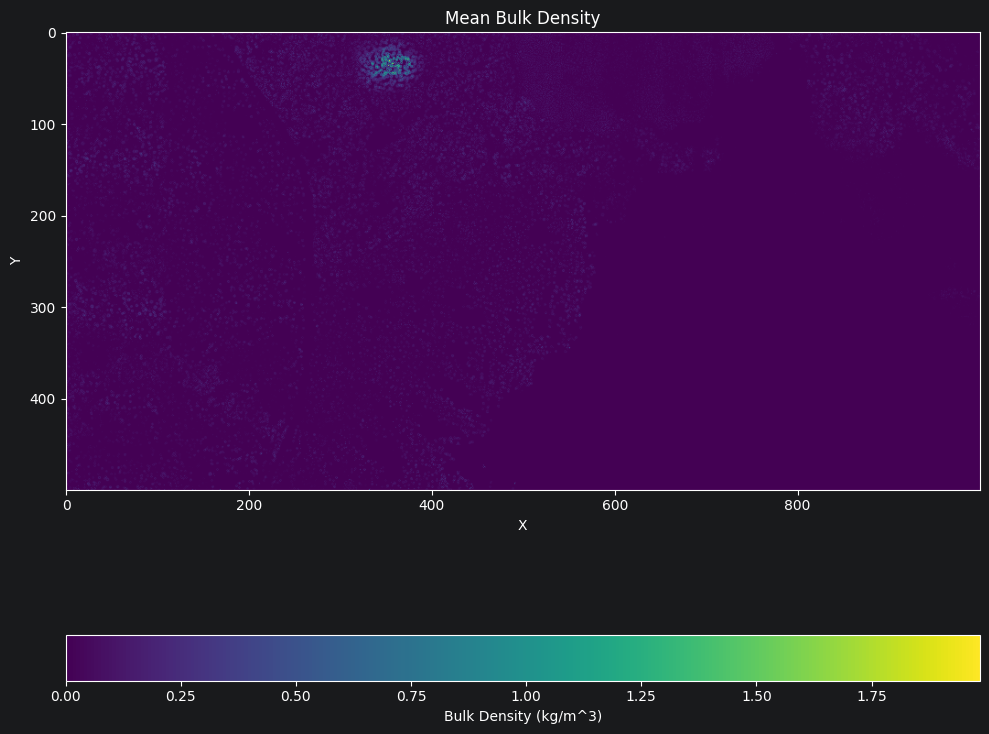

In [34]:
# Plot the bulk density grid summed across the z-axis
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(ff_voxelized_tree_data_bulk_density[...].mean(axis=0), cmap="viridis")
ax.set_title("Mean Bulk Density")
ax.set_xlabel("X")
ax.set_ylabel("Y")
fig.colorbar(im, ax=ax, label="Bulk Density (kg/m^3)", orientation="horizontal")
plt.tight_layout()
plt.show()

# LANL TREES

### Prep Wade's trees for LANL TREES

### Run LANL TREES

# Compare Outputs